<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%BC%D0%B5%D1%81%D1%82%D0%BE%D1%80%D0%BE%D0%B6%D0%B4%D0%B5%D0%BD%D0%B8%D0%B9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
from google.colab import files
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier

np.random.seed(42)

In [3]:
files.upload()
!unzip classification-of-oil-and-gas.zip

Saving classification-of-oil-and-gas.zip to classification-of-oil-and-gas.zip
Archive:  classification-of-oil-and-gas.zip
  inflating: oil_test.csv            
  inflating: train_oil.csv           


In [4]:
# Чтение наборов данных
df = pd.read_csv("train_oil.csv")
df_test = pd.read_csv("oil_test.csv")

# Удаление полных дубликатов. Не найдено в данных, но на всякий случай
df.drop_duplicates()
df_test.drop_duplicates()
df.nunique()

,0
Field name,285
Reservoir unit,258
Country,42
Region,7
Basin name,93
Tectonic regime,55
Latitude,262
Longitude,260
Operator company,138
Onshore/Offshore,3


Название и юнит месторождения, а также название компании содержат слишком много уникальных нечисловых значений, не дадут полезной информации для классификации, лучше их удалить. В странах есть псевдоразные значения - UK/NORWAY и NORWAY/UK - далее приведем к общему виду.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

Страна, регион, название бассейна, широта, долгота - география месторождения. Она не везде указана, но оставим эти строки, заполнив их одним значением, чтобы не потерять часть информации. Пропуски по географическим параметрам сильно коррелируют (если нет одного, очень часто нет и остальных).

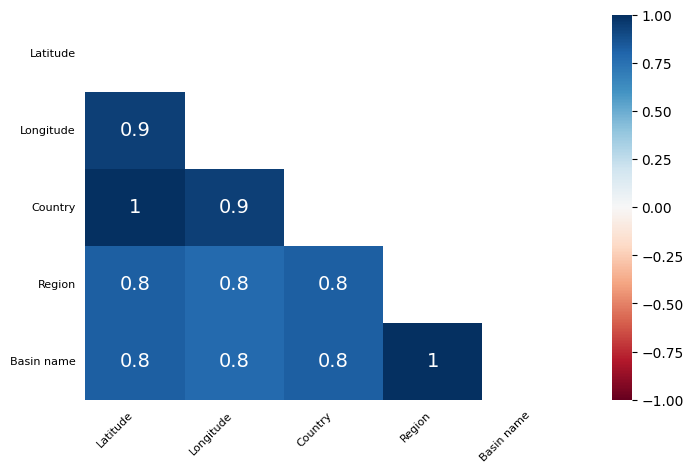

In [6]:
# Корреляция пропусков географических данных
fig, ax = plt.subplots(figsize=(8, 5))
msno.heatmap(df[['Latitude','Longitude','Country','Region','Basin name']], ax=ax)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Гипотеза - если страна не указана, то месторождение чаще в море:

In [7]:
df_country_missing = df.copy()
df_country_missing['Country_missing'] = df_country_missing['Country'].isna()

df_country_missing.groupby('Country_missing')['Onshore/Offshore'].value_counts(normalize=True)

Country_missing  Onshore/Offshore
False            ONSHORE             0.698582
                 OFFSHORE            0.287234
                 ONSHORE-OFFSHORE    0.014184
True             ONSHORE             0.777778
                 OFFSHORE            0.185185
                 ONSHORE-OFFSHORE    0.037037
Name: proportion, dtype: float64

Гипотеза не подтверждается. Чаще (примерно 78% против 19%) как раз бывает наоборот.

In [8]:
# Преодбработка. Удаление неинформативных признаков, нормализация названия страны, заполнение пропусков числовых признаков медианой и Unknown для категориальных.
def preprocess(dfr,
               cols_number=['Latitude', 'Longitude', 'Depth', 'Thickness (net pay average ft)', 'Thickness (gross average ft)', 'Porosity', 'Permeability'],
               cols_object=['Country', 'Region', 'Tectonic regime', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology'],
               del_columns=['Field name', 'Reservoir unit', 'Basin name', 'Operator company']):
    df = dfr.copy()
    df = df.drop(columns=del_columns, errors='ignore')

    df['Country'] = (
        df['Country']
        .fillna('Unknown')
        .str.split('/')
        .apply(lambda x: '/'.join(sorted(s.strip() for s in x)))
    )

    df[cols_number] = df[cols_number].fillna(df[cols_number].median())
    df[cols_object] = df[cols_object].fillna('Unknown')

    return df

In [9]:
# Явное указание колонок - числовые и категориальные признаки
cols_number = ['Latitude', 'Longitude', 'Depth', 'Thickness (net pay average ft)', 'Thickness (gross average ft)', 'Porosity', 'Permeability']
cols_object = ['Country', 'Region', 'Tectonic regime', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']

# Предобработка
df = preprocess(df)
df_test = preprocess(df_test)

# Кодирование целевой переменной согласно ожиданиям Kaggle
df['Onshore/Offshore'] = df['Onshore/Offshore'].map({'ONSHORE': 1, 'OFFSHORE': 0, 'ONSHORE-OFFSHORE': 2})

# Стандартизация для регрессии и KNN и кодирование категориальных признаков
scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False) #handle_unknown='ignore',

df_s = df.copy()
df_test_s = df_test.copy()

df_l = pd.concat(
        [df.drop(columns=['Onshore/Offshore']), df_test],
        axis=0
    )

scaler.fit(df_l[cols_number])
encoder.fit(df_l[cols_object])

df_s[cols_number] = scaler.transform(df[cols_number])
df_test_s[cols_number] = scaler.transform(df_test[cols_number])

X_cat = pd.DataFrame(encoder.transform(df[cols_object]), columns=encoder.get_feature_names_out(cols_object))
X_train = pd.concat(
    [X_cat, df_s[cols_number].reset_index(drop=True)],
    axis=1
)

X_s_cat = pd.DataFrame(encoder.transform(df_test[cols_object]), columns=encoder.get_feature_names_out(cols_object))
X_test = pd.concat(
    [X_s_cat, df_test_s[cols_number].reset_index(drop=True)],
    axis=1
)

При исследовании числовых признаков наблюдается заметная нелинейность и множество различных выбросов. Распределения сильно скошены. Логарифмирование позволяет симметризовать и уменьшить разброс.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_8790/3082445499.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_8790/3082445499.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/tmp/ipykernel_8790/3082445499.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


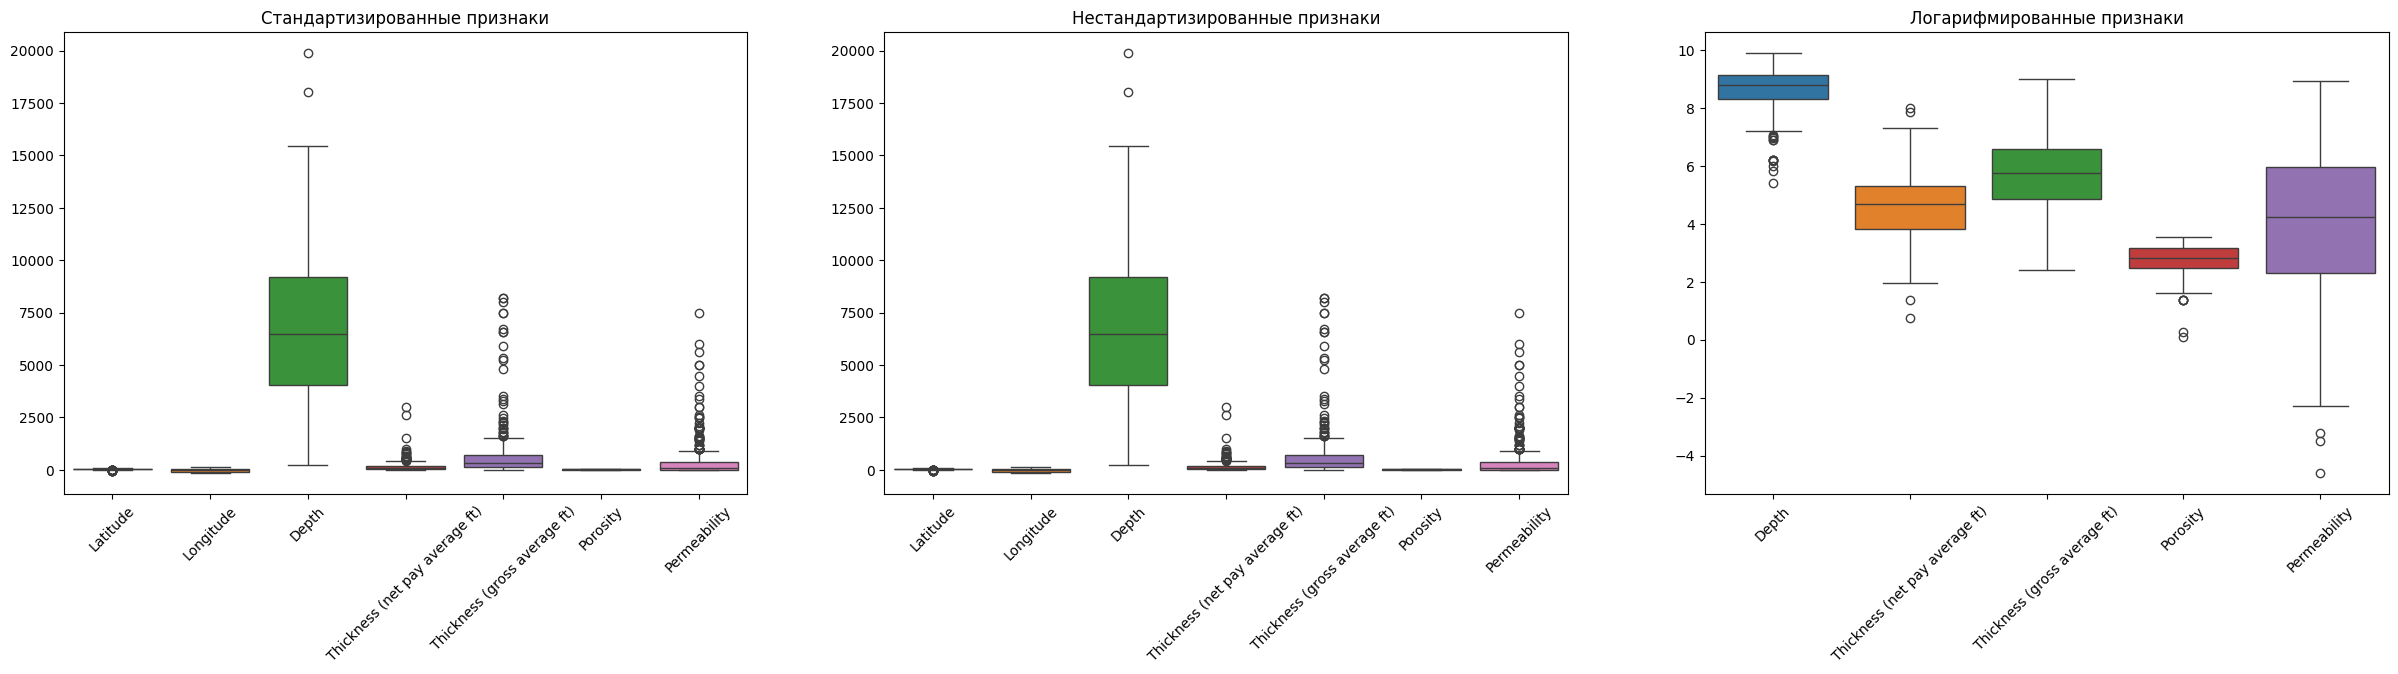

In [10]:
df_t = df.copy()
df_t['Depth'] = np.log(df_t['Depth'])
df_t['Permeability'] = np.log(df_t['Permeability'])
df_t['Thickness (net pay average ft)'] = np.log(df_t['Thickness (net pay average ft)'])
df_t['Thickness (gross average ft)'] = np.log(df_t['Thickness (gross average ft)'])
df_t['Porosity'] = np.log(df_t['Porosity'])

df_t['Thickness (net pay average ft)'] = df_t['Thickness (net pay average ft)'].replace(-np.inf, 0)

df_t_test = df_test.copy()
df_t_test['Depth'] = np.log(df_t_test['Depth'])
df_t_test['Permeability'] = np.log(df_t_test['Permeability'])
df_t_test['Thickness (net pay average ft)'] = np.log(df_t_test['Thickness (net pay average ft)'])
df_t_test['Thickness (gross average ft)'] = np.log(df_t_test['Thickness (gross average ft)'])
df_t_test['Porosity'] = np.log(df_t_test['Porosity'])

df_t_test['Thickness (net pay average ft)'] = df_t_test['Thickness (net pay average ft)'].replace(-np.inf, 0)

df_s = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(30, 6))

sns.boxplot(data=df_s[cols_number], ax=axes[0])
axes[0].set_title('Стандартизированные признаки')

sns.boxplot(data=df[cols_number], ax=axes[1])
axes[1].set_title('Нестандартизированные признаки')

sns.boxplot(data=df_t[cols_number].drop(columns=['Latitude', 'Longitude']), ax=axes[2])
axes[2].set_title('Логарифмированные признаки')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
# plt.tight_layout()
plt.show()

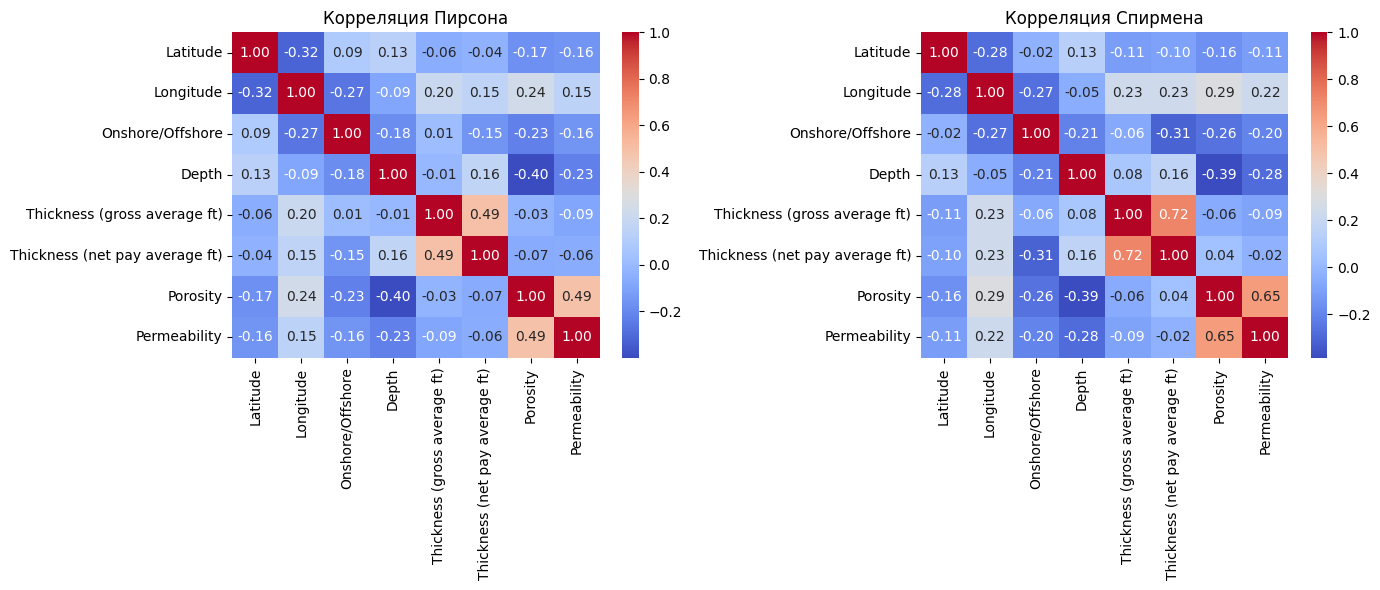

In [11]:
corr_pearson = df.corr(method='pearson', numeric_only=True)
corr_spearman = df.corr(method='spearman', numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title('Корреляция Пирсона')

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title('Корреляция Спирмена')

plt.tight_layout()
plt.show()

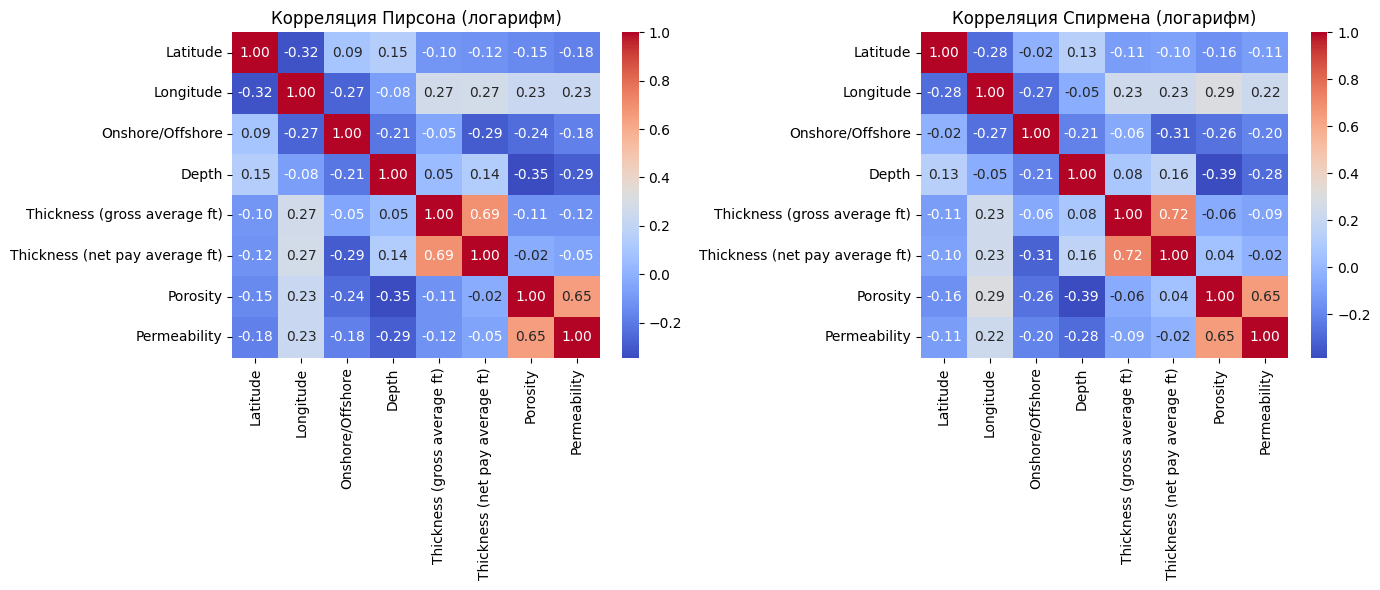

In [12]:
corr_pearson = df_t.corr(method='pearson', numeric_only=True)
corr_spearman = df_t.corr(method='spearman', numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title('Корреляция Пирсона (логарифм)')

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title('Корреляция Спирмена (логарифм)')

plt.tight_layout()
plt.show()

In [13]:
y_train = df_s['Onshore/Offshore']

Реализация логистической регрессии в scikit-learn автоматически строит нужное число регрессий, если классов больше 2 (в нашем случае 3)

In [14]:
model_log_regression = LogisticRegression(C=3, max_iter=2000, class_weight='balanced')

model_log_regression.fit(X_train, y_train)

y_pred = model_log_regression.predict(X_test)

print (y_train)
print (y_pred)
print (pd.Series(y_pred).value_counts(normalize=True))
print (y_train.value_counts(normalize=True))

0      1
1      1
2      1
3      0
4      1
      ..
304    1
305    1
306    1
307    1
308    1
Name: Onshore/Offshore, Length: 309, dtype: int64
[1 1 1 0 0 0 0 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1 2 0 0 1 0 0 1 1 1 1 1 2 1
 1 1 0 0 1 0 1 0 1 1 1 1 1 0 0 0 1 2 1 1 0 1 1 2 1 0 1 1 0 1 1 1 1 1 1 0 1
 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 2 0 0 1 1 1 1 1 1 0 0 1 0 1 1 1 1
 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]
1    0.676692
0    0.285714
2    0.037594
Name: proportion, dtype: float64
Onshore/Offshore
1    0.705502
0    0.278317
2    0.016181
Name: proportion, dtype: float64


Так как нет тестовых данных отдельно (с правильными ответами), можно оценить точность с помощью кросс-валидации (сильно занижает оценку относительно Kaggle) - мало данных для обучения при сильном дисбалансе классов, чтобы адекватно оценить или отделить от обучающей выборки часть на тест.

In [15]:
scores = cross_val_score(model_log_regression, X_train, y_train, cv=5, scoring='f1_macro')

print("Scores:", scores)
print("Mean:", scores.mean())

Scores: [0.55793226 0.52142857 0.53880679 0.57509158 0.58127341]
Mean: 0.5549065211314226


Наблюдается только умеренная положительная линейная связь общей и эффективной толщины, а также пористости и проницаемости, что согласуется с физической картиной. При сравнении с ранговой корреляцией видно, что эта связь монотонна и имеет нелинейную составляющую.

Также для улучшения качества классификации имеет смысл ввести еще 2 числовых признака, которые следуют из физической природы месторождений. Во-первых, в отрасли используется показатель NTG (net to gross) - отношение эффективной толщины к общей. Этот признак более равномерно распределен, чем толщины по отдельности. Во-вторых, связь проницаемости $k$ и пористости $\phi$ имеет следующий вид (уравнение Козени-Кармана):

$$
k \sim \frac{\phi^3}{(1 - \phi)^2}
$$

Коэффициент пропорциональности зависит от удельной площади частиц и структуры каналов проникновения влаги - невозможно оценить из имеющихся данных. Однако из общих соображений понятно, что чем больше глубина, тем меньше должны быть проницаемость и пористость. Будем рассматривать произведение $k$, выраженного через $\phi$, и глубины

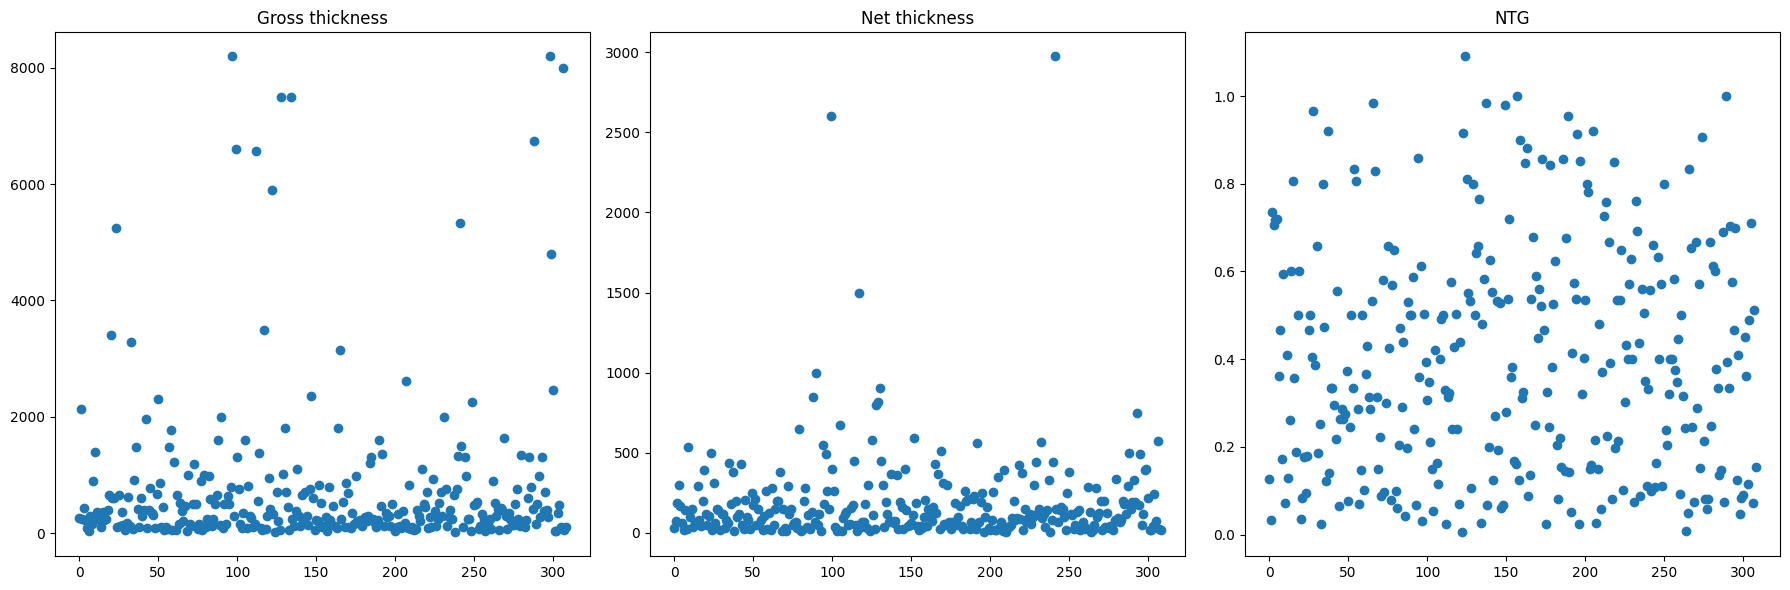

In [16]:
df['NTG'] = df['Thickness (net pay average ft)'] / df['Thickness (gross average ft)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(range(len(df)), df['Thickness (gross average ft)'])
axes[0].set_title('Gross thickness')

axes[1].scatter(range(len(df)), df['Thickness (net pay average ft)'])
axes[1].set_title('Net thickness')

axes[2].scatter(range(len(df)), df['NTG'])
axes[2].set_title('NTG')

plt.tight_layout()
plt.show()

In [17]:
def add_features(dfr):
    df = dfr.copy()
    df['poro_depth'] = df['Porosity'] ** 3 / ((1 - df['Porosity']) ** 2) * (df['Depth'])
    df['NTG'] = df['Thickness (net pay average ft)'] / df['Thickness (gross average ft)']
    return df

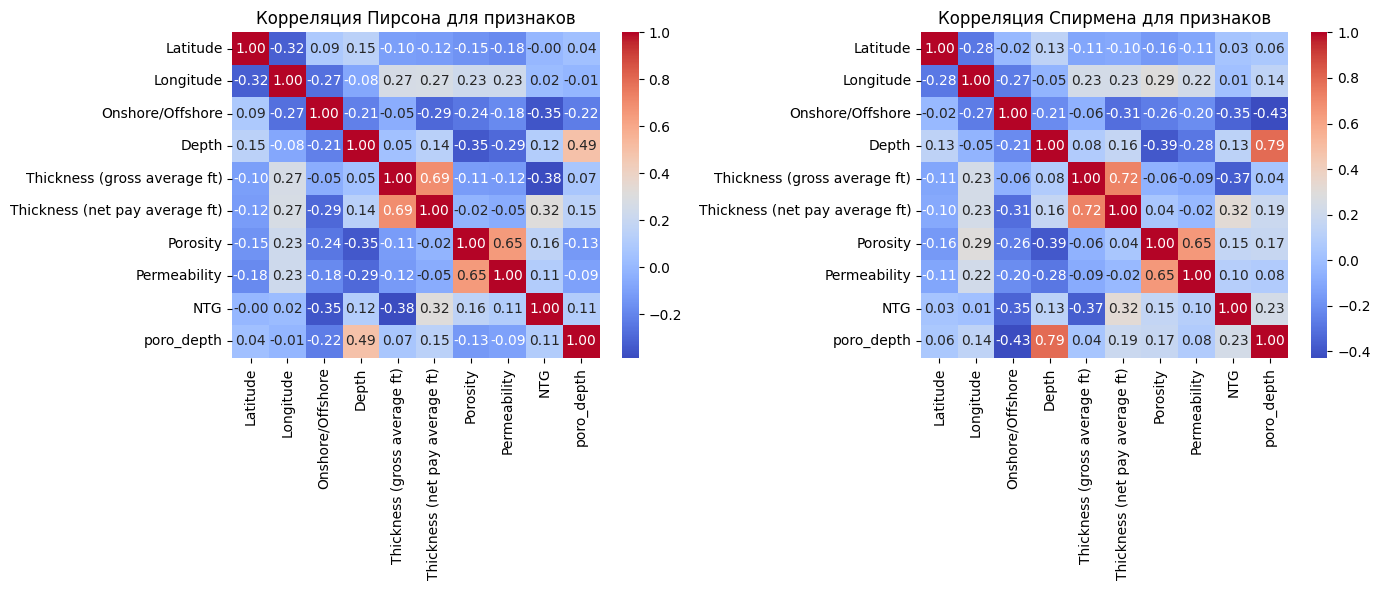

In [18]:
# Новые добавленные признаки
df_add = add_features(df)
df_test_add = add_features(df_test)

# Остальные переносим из логарифмирования выше
df_add['Depth'] = df_t['Depth']
df_add['Permeability'] = df_t['Permeability']
df_add['Thickness (net pay average ft)'] = df_t['Thickness (net pay average ft)']
df_add['Thickness (gross average ft)'] = df_t['Thickness (gross average ft)']
df_add['Porosity'] = df_t['Porosity']

df_test_add['Depth'] = df_t_test['Depth']
df_test_add['Permeability'] = df_t_test['Permeability']
df_test_add['Thickness (net pay average ft)'] = df_t_test['Thickness (net pay average ft)']
df_test_add['Thickness (gross average ft)'] = df_t_test['Thickness (gross average ft)']
df_test_add['Porosity'] = df_t_test['Porosity']

corr_pearson = df_add.corr(method='pearson', numeric_only=True)
corr_spearman = df_add.corr(method='spearman', numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title('Корреляция Пирсона для признаков')

sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title('Корреляция Спирмена для признаков')

plt.tight_layout()
plt.show()

Видно, что дополнительные признаки больше коррелируют с целевой переменной

In [19]:
# Повторная стандартизация и кодирование с учетом новых признаков
cols_number_add = ['Latitude', 'Depth', 'Longitude', 'Porosity', 'Thickness (net pay average ft)', 'Thickness (gross average ft)', 'Permeability', 'poro_depth', 'NTG']

scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False)

df_s = df_add.copy()
df_s_test = df_test_add.copy()

df_l = pd.concat(
        [df_add.drop(columns=['Onshore/Offshore']), df_test_add],
        axis=0
    )

scaler.fit(df_l[cols_number_add])
encoder.fit(df_l[cols_object])

df_s[cols_number_add] = scaler.transform(df_add[cols_number_add])
df_s_test[cols_number_add] = scaler.transform(df_test_add[cols_number_add])

X_cat = pd.DataFrame(encoder.transform(df_add[cols_object]), columns=encoder.get_feature_names_out(cols_object))
X_train = pd.concat(
    [X_cat, df_s[cols_number_add].reset_index(drop=True)],
    axis=1
)
y_train = df_add['Onshore/Offshore']

X_cat = pd.DataFrame(encoder.transform(df_test_add[cols_object]), columns=encoder.get_feature_names_out(cols_object))
X_test = pd.concat(
    [X_cat, df_s_test[cols_number_add].reset_index(drop=True)],
    axis=1
)

In [20]:
# Классификация методом логистической регрессии. Включена балансировка классов - выше результат на Kaggle
model_log_regression = LogisticRegression(C=3, max_iter=2000, class_weight='balanced')

model_log_regression.fit(X_train, y_train)

y_pred = model_log_regression.predict(X_test)

print (y_train)
print (y_pred)
print (pd.Series(y_pred).value_counts(normalize=True))

submission = pd.DataFrame(
    {'Onshore/Offshore': y_pred.ravel()},
    index=range(len(y_pred))
)

submission.to_csv(
    'log_regressi.csv',
    index=True,
    index_label='index'
)

0      1
1      1
2      1
3      0
4      1
      ..
304    1
305    1
306    1
307    1
308    1
Name: Onshore/Offshore, Length: 309, dtype: int64
[1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1 2 0 0 1 0 0 1 1 1 1 1 0 1
 1 1 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1 2 0 1 1 1 1 2 1 0 1 1 0 1 1 1 1 1 1 0 1
 0 1 2 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 2 0 0 1 1 1 0 1 1 2 0 1 0 1 1 1 1
 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1]
1    0.654135
0    0.300752
2    0.045113
Name: proportion, dtype: float64


In [21]:
scores = cross_val_score(model_log_regression, X_train, y_train, cv=5, scoring='f1_macro')

print("Scores:", scores)
print("Mean:", scores.mean())

Scores: [0.53074866 0.52654303 0.51209633 0.60162602 0.58866279]
Mean: 0.5519353662015065


In [22]:
param_grid = {
    'C': [2, 3, 4],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 4, 'class_weight': None}
0.5706170311702169


In [23]:
# Классификация методом K ближайших соседей
model_knn = KNeighborsClassifier(n_neighbors=3)

model_knn.fit(X_train, y_train)

model_knn.predict(X_test)

scores = cross_val_score(model_knn, X_train, y_train, cv=5, scoring='f1_macro')

print("Scores:", scores)
print("Mean:", scores.mean())

submission = pd.DataFrame(
    {'Onshore/Offshore': y_pred.ravel()},
    index=range(len(y_pred))
)

submission.to_csv(
    'KNN.csv',
    index=True,
    index_label='index'
)

Scores: [0.49287926 0.60872439 0.48722861 0.56969697 0.54127482]
Mean: 0.5399608080699841


In [24]:
# Повторная сборка данных для обучения без стандартизации для методов, не основанных на метриках расстояния
encoder = OneHotEncoder(sparse_output=False)

df_l = pd.concat(
        [df_add.loc[:, cols_object], df_test_add.loc[:, cols_object]],
        axis=0
    )

encoder.fit(df_l)

X_cat = pd.DataFrame(encoder.transform(df_add.loc[:, cols_object]), columns=encoder.get_feature_names_out(cols_object), index=df_add.index)
X_train = pd.concat(
    [X_cat, df_add[cols_number_add].reset_index(drop=True)],
    axis=1
)
y_train = df_add['Onshore/Offshore']

X_cat = pd.DataFrame(encoder.transform(df_test_add.loc[:, cols_object]), columns=encoder.get_feature_names_out(cols_object), index=df_test_add.index)
X_test = pd.concat(
    [X_cat, df_test_add[cols_number_add].reset_index(drop=True)],
    axis=1
)

In [25]:
# Классификация методом дерева решений
model_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_leaf=1,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42)

model_tree.fit(X_train, y_train)

scores = cross_val_score(model_tree, X_train, y_train, cv=5, scoring='f1_macro')

y_pred = model_tree.predict(X_test)

print("Scores:", scores)
print("Mean:", scores.mean())

submission = pd.DataFrame(
    {'Onshore/Offshore': y_pred.ravel()},
    index=range(len(y_pred))
)

submission.to_csv(
    'tree.csv',
    index=True,
    index_label='index'
)

Scores: [0.4838256  0.48495935 0.42828283 0.49528598 0.52374031]
Mean: 0.4832188138723138


In [26]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 3, 4, 5, 8, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6],
    'class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    estimator=model_tree,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}
0.6173917703695933


In [27]:
# Классификация методом случайного леса
model_rand_forest = RandomForestClassifier(
    n_estimators=200,
    max_features='log2',
    criterion='gini',
    min_samples_leaf=1,
    min_samples_split=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rand_forest.fit(X_train, y_train)

y_pred = model_rand_forest.predict(X_test)

scores = cross_val_score(model_rand_forest, X_train, y_train, cv=5, scoring='f1_macro')

print("Scores:", scores)
print("Mean:", scores.mean())

submission = pd.DataFrame(
    {'Onshore/Offshore': y_pred.ravel()},
    index=range(len(y_pred))
)

submission.to_csv(
    'Forest.csv',
    index=True,
    index_label='index'
)

Scores: [0.56965872 0.59393939 0.50490884 0.59632035 0.55722139]
Mean: 0.5644097368994597


In [28]:
param_grid = {
    # 'n_estimators': [200, 300, 400],
    'max_depth': [17, 23, 27],
    'min_samples_split': [3, 4],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=model_rand_forest,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 27, 'min_samples_leaf': 1, 'min_samples_split': 3}
0.5644097368994597


In [29]:
cols_object = ['Country', 'Region', 'Tectonic regime', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Hydrocarbon type', 'Lithology']
X_train = df_add.drop(columns=['Onshore/Offshore'])
y_train = df_add['Onshore/Offshore']
X_test = df_test_add

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, test_index in cv.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
    y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]

    model_cat = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='MultiClass',
        random_seed=42,
        verbose=0,
        cat_features=cols_object
    )

    model_cat.fit(X_train_fold, y_train_fold, cat_features=cols_object)

    y_pred = model_cat.predict(X_test_fold).ravel()

    scores.append(f1_score(y_test_fold, y_pred, average='macro'))

print("Scores:", scores)
print("Mean:", np.mean(scores))

model_cat = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0,
    cat_features=cols_object
)

model_cat.fit(X_train, y_train, cat_features=cols_object)

y_pred = model_cat.predict(X_test)

submission = pd.DataFrame(
    {'Onshore/Offshore': y_pred.ravel()},
    index=range(len(y_pred))
)

submission.to_csv(
    'CatBoost.csv',
    index=True,
    index_label='index'
)

Scores: [0.5545778336476012, 0.5663299663299664, 0.5277573978967963, 0.5336605890603086, 0.5328554360812425]
Mean: 0.5430362446031831


In [30]:
importance = pd.Series(
    model_cat.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

Region                            10.905842
Reservoir period                   9.731102
Structural setting                 9.218773
Country                            8.844383
Thickness (net pay average ft)     8.833251
Reservoir status                   8.375521
poro_depth                         7.693305
Lithology                          6.240418
Tectonic regime                    5.603758
Hydrocarbon type                   5.077177
Longitude                          4.034736
Latitude                           3.635592
NTG                                2.925415
Thickness (gross average ft)       2.886462
Depth                              2.321921
Porosity                           2.055842
Permeability                       1.616501
dtype: float64


По оценкам кросс-валидации лучшее соответствие можно получить на дереве решений, но подобранные параметры выглядят так, что дерево окажется сильно переобученным, что даст плохой результат на тестовой выборке. Это подтверждается оценкой на Kaggle. Наилучший результат получается при использовании случайного леса. Остальные методы (кроме дерева решений) дают очень близкие результаты.

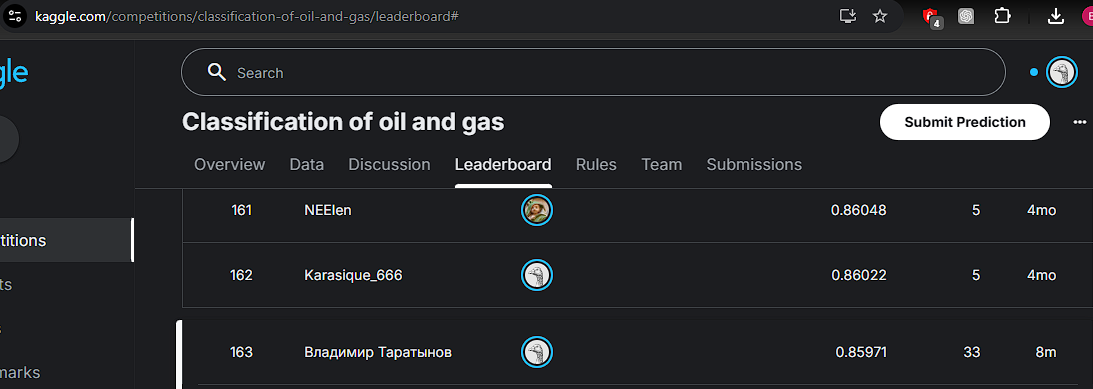